*WHY OPTIMIZATION IS REQUIRED?*

In modern 6G wireless networks, resource allocation is a multi-objective optimization problem due to the conflicting nature of network performance metrics. Increasing transmit power may improve throughput but simultaneously increases energy consumption and operational cost. Similarly, allocating additional bandwidth to one user improves its Quality of Service (QoS) while reducing the resources available for others. Therefore, an optimization framework is required to determine the optimal allocation of communication resources while satisfying practical network constraints.

*PROBLEM STATEMENT*

Given multiple users connected to multiple base stations through multiple wireless channels, determine the optimal allocation of transmit power, bandwidth, channels, and resource blocks such that energy consumption, latency, and operational cost are minimized while throughput and bandwidth utilization are maximized.

*OPTIMIZATION VARIABLES*

Channel Assignment: X(i,j)= 1 if user i is assigned to channel j, 0 otherwise

Transmit power: Pi

Bandwidth: Bi

Resource Blocks: RBi

![alt text](image.png)

Only one channel allocated for one person at a time.
Packet loss should be less than 5%.

Throughtput to be more than minimum throughput(20Mbps).

In [2]:
import pandas as pd

df = pd.read_csv("research_grade_6g_synthetic_dataset_10000.csv")

df.head()

,User_ID,Base_Station_ID,Channel_ID,Distance_m,Carrier_Freq_GHz,Path_Loss_dB,Beamforming_Gain_dB,Tx_Power_W,Rx_Power_dBm,Interference_dBm,...,Network_Load,Packet_Size_MB,Throughput_Mbps,Latency_ms,Energy_J,Cost,User_Speed_kmph,Packet_Loss_%,QoS_Class,Priority
0,1,3,4,436.10,3.5,95.09,8.90,0.282,-31.70,-98.83,...,0.291,5.04,109.59,2.76,0.104,0.393,80.5,0.0,eMBB,Medium
1,2,1,8,258.99,28.0,103.36,9.92,0.452,-36.90,-87.39,...,0.868,6.19,83.71,5.41,0.267,0.481,28.6,0.0,mMTC,Low
2,3,5,1,437.07,2.6,95.31,16.12,0.794,-20.19,-86.62,...,0.881,7.57,110.20,5.34,0.436,0.656,104.5,0.0,mMTC,Low
3,4,4,7,342.33,2.6,81.19,18.67,1.596,-0.49,-81.40,...,0.686,0.89,268.71,3.76,0.042,1.299,91.3,0.0,eMBB,High
4,5,1,5,87.67,3.5,63.59,17.76,0.542,11.51,-88.58,...,0.523,6.89,664.13,3.33,0.045,1.272,82.1,0.0,eMBB,Low


In [3]:
MAX_POWER = 20

TOTAL_BW = 100

TOTAL_RB = 275

MIN_SINR = 10

MAX_LATENCY = 10

In [4]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "Throughput_Mbps",
    "Energy_J",
    "Latency_ms",
    "Cost",
    "Allocated_BW_MHz"
]

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(df[cols])

In [5]:
w1 = 0.35
w2 = 0.25
w3 = 0.20
w4 = 0.10
w5 = 0.10

df["Fitness"] = (
    w1 * df["Throughput_Mbps"]
    - w2 * df["Energy_J"]
    - w3 * df["Latency_ms"]
    - w4 * df["Cost"]
    + w5 * df["Allocated_BW_MHz"]
)

In [6]:
constraint_1 = (
    df.groupby("User_ID")["Channel_ID"].count() == 1
).all()

constraint_2 = (
    df["Tx_Power_W"].sum() <= MAX_POWER
)

constraint_3 = (
    df["SINR_dB"] >= MIN_SINR
).all()

constraint_4 = (
    df["Latency_ms"] <= MAX_LATENCY
).all()

print(constraint_1)
print(constraint_2)
print(constraint_3)
print(constraint_4)

True
False
True
True


In [7]:
df.sort_values(
    by="Fitness",
    ascending=False
).head(20)

,User_ID,Base_Station_ID,Channel_ID,Distance_m,Carrier_Freq_GHz,Path_Loss_dB,Beamforming_Gain_dB,Tx_Power_W,Rx_Power_dBm,Interference_dBm,...,Packet_Size_MB,Throughput_Mbps,Latency_ms,Energy_J,Cost,User_Speed_kmph,Packet_Loss_%,QoS_Class,Priority,Fitness
1145,1146,4,7,79.34,3.5,64.49,16.49,0.354,7.50,-103.61,...,3.70,0.869060,0.020794,0.002491,0.825032,110.7,0.0,URLLC,Low,0.316886
8211,8212,4,1,104.49,0.7,58.05,19.53,1.956,24.39,-102.10,...,6.01,1.000000,0.224953,0.017435,0.995743,1.8,0.0,URLLC,Medium,0.301077
2858,2859,4,4,49.62,2.6,60.95,14.59,0.581,11.28,-102.86,...,6.53,0.896629,0.158790,0.006227,0.849298,27.8,0.0,eMBB,Low,0.295576
1099,1100,3,1,91.53,3.5,67.32,19.79,0.526,9.68,-106.63,...,6.09,0.897655,0.306238,0.005604,0.843338,20.3,0.0,eMBB,Medium,0.267197
8744,8745,1,4,96.25,3.5,70.18,18.33,0.788,7.11,-90.90,...,7.55,0.783465,0.136106,0.011208,0.871222,26.6,0.0,mMTC,Medium,0.257067
43,44,5,8,373.66,3.5,89.92,18.09,1.023,-11.74,-108.95,...,8.65,0.728422,0.058601,0.018057,0.896339,40.4,0.0,eMBB,Low,0.249079
6884,6885,5,8,254.91,0.7,71.92,8.12,0.944,-4.06,-93.54,...,3.20,0.712501,0.117202,0.006227,0.887825,42.0,0.0,mMTC,Medium,0.235596
8132,8133,3,1,70.66,2.6,63.23,6.59,0.577,0.98,-99.33,...,1.02,0.793485,0.289225,0.001245,0.848872,111.1,0.0,mMTC,Medium,0.234676
9508,9509,4,4,249.51,0.7,73.44,14.27,0.561,-1.68,-80.94,...,2.87,0.631950,0.034026,0.003736,0.846956,83.8,0.0,URLLC,Medium,0.228747
3660,3661,5,2,24.94,3.5,53.75,12.70,0.343,14.31,-90.82,...,5.47,0.841570,0.434783,0.003113,0.823968,115.2,0.0,eMBB,High,0.224418


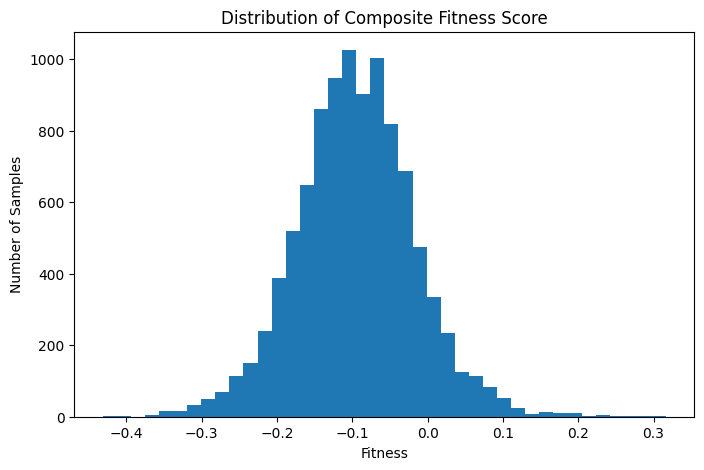

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Fitness"], bins=40)
plt.xlabel("Fitness")
plt.ylabel("Number of Samples")
plt.title("Distribution of Composite Fitness Score")
plt.show()

*CONCLUSION*

In this notebook, we have formulated a mathematical problem to optimize multiple problem. This formulation establishes the mathematical foundation for the remainder of the project. In the next notebook, the optimization problem will be solved using a classical optimization algorithm (e.g., Integer Linear Programming or a Genetic Algorithm). These classical results will serve as a benchmark before reformulating the same problem as a QUBO and solving it using the Quantum Approximate Optimization Algorithm (QAOA), enabling a direct comparison between classical and quantum optimization approaches.